In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
#             print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
#     print(valid_dirs)
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [3]:
!diff ../wexac_saved_runs/NMNIST_seeds_578873/config.yaml ../wexac_saved_runs/NMNIST_seeds_578872/config.yaml

8c8
< - 10.0
---
> - 2.0
29c29
< job_id: '578873'
---
> job_id: '578872'
31,32c31,32
< json_log: ./saved_runs/NMNIST_seeds_578873/results/epoch_data.json
< json_test_data: ./saved_runs/NMNIST_seeds_578873/results/test_data.json
---
> json_log: ./saved_runs/NMNIST_seeds_578872/results/epoch_data.json
> json_test_data: ./saved_runs/NMNIST_seeds_578872/results/test_data.json
56c56
< run_name: NMNIST_seeds_578873
---
> run_name: NMNIST_seeds_578872


In [4]:
min_epoch = 0
use_test = True
search_path = '../wexac_saved_runs/'

ref_config_paths = {
#                     'jitter_test':'../wexac_saved_runs/retest_mnist20p_augjit_747184_/config.yaml',
#                     'jitter_training': '../wexac_saved_runs/retest_mnist20p_augjit_920515_/config.yaml',
                    'jitter_both': '../wexac_saved_runs/NMNIST_seeds_578873/config.yaml',
                    }

config_ignore_fields_s = {
#                         'jitter_test':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
#                         'json_test_data', 'ds_args_augment_per_event_shifts',
#                                             'pretrained_model_path','check_job_recovery'],
#                         'jitter_training':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
#                         'json_test_data', 'ds_args_augment_per_event_shifts',
#                                             'pretrained_model_path','check_job_recovery'],
                        'jitter_both': ['json_log', 'run_name', 'seed', 'ds_args_n_samples', 'job_id',
                        'json_test_data', 'ds_args_augment_per_event_shifts', 'pretrained_model_path'],

                       }
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')

found 70 runs for mode jitter_both


In [5]:
#for jitter in train only we need a hack to recover the original jitter value
def extract_source_run(x):
    return x.split('/')[-2]
def extract_train_jitter(x):
    return dfs['jitter_both'].loc[extract_source_run(x)]['ds_args_augment_per_event_shifts']

In [6]:
dfs.keys()

dict_keys(['jitter_both'])

In [7]:
# dfs['jitter_both']['ds_args_augment_per_event_shifts'] = \
#     dfs['jitter_both'].apply(lambda row: extract_train_jitter(row['config_file']),axis=1)

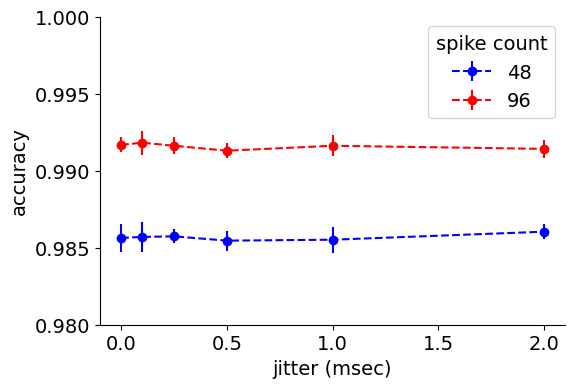

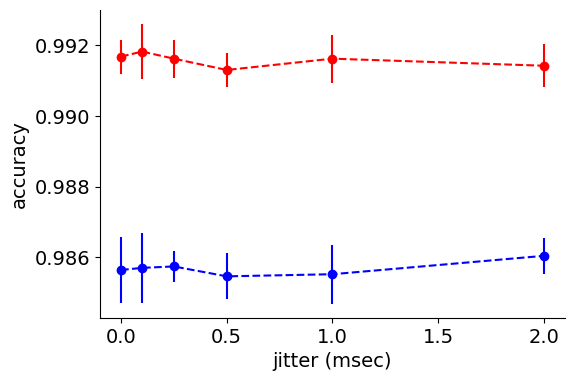

In [33]:
fig = plt.figure(1,figsize=(6,4))
plt.rcParams.update({'font.size': 14})
ax1=plt.gca()

plt.figure(2,figsize=(6,4))
plt.rcParams.update({'font.size': 14})
ax2=plt.gca()



# jitter_vals = [0.0, 0.25, 0.50, 1.0, 2.0, 10]
jitter_vals = [0.0, 0.1, 0.25, 0.50, 1.0, 2.0]
plt_clr = ['b', 'r', 'g', 'm', 'y']
styles = ['--o', '--x',':d']
# fig,(ax1,ax2)=plt.subplots(1,2, figsize=(12,4))

modes = []
for tt, (this_mode, df_ds)  in enumerate(dfs.items()):
# Convert lists in 'ds_args_augment_per_event_shifts' to tuples
    modes.append(this_mode)
    df_ds['ds_args_augment_per_event_shifts'] = df_ds['ds_args_augment_per_event_shifts'].apply(tuple)

    for ax in [ax1,ax2]:
        spike_counts = df_ds['ds_args_n_samples'].unique()
        for ind, spike_cnt in enumerate(spike_counts):
            df_slice = df_ds[df_ds['ds_args_n_samples'] == spike_cnt]
            df_grp = df_slice.groupby(['ds_args_augment_per_event_shifts']).aggregate({'seed':'count', 'test_acc':['mean','std']})
            df_grp = df_grp.reindex([tuple([jit, 0, 0, 0]) for jit in jitter_vals])  # ensure the same order for plotting

            ax.errorbar(jitter_vals, df_grp['test_acc']['mean'], df_grp['test_acc']['std'], fmt=styles[tt]+plt_clr[ind])

            ###inset to save the results
            df_for_saving = df_grp.copy()
            df_for_saving.index = df_for_saving.index.map(lambda x: x[0])
            df_for_saving.index.name = "jitter"
            df_for_saving.index = df_out.index.map(lambda x: x[0] if isinstance(x, tuple) else x)
            df_for_saving.index.name = "jitter"
            
            # 2. Flatten MultiIndex columns like ('test_acc', 'mean') -> 'test_acc_mean'
            if isinstance(df_for_saving.columns, pd.MultiIndex):
                df_for_saving.columns = [
                    "_".join(str(part) for part in col if str(part) != "")
                    for col in df_for_saving.columns
                    ]
            
            df_for_saving.to_csv(f'fig2panelE_numEvents{spike_cnt}.csv')
            
        ax.set_ylabel('accuracy')

        ax.set_xlabel('jitter (msec)')
        ax.spines[['right', 'top']].set_visible(False)
    
    ax1.legend([str(sc) for sc in spike_counts], title='spike count')
    ax1.set_ylim([0.98, 1])
#     ax2.set_ylim([0.84, 0.94])
#     ax2.set_xlim([-0.02, 0.5])

fig.savefig('fig2panelE.svg',format='svg')
# add_inset_with_symbols(ax1, width="15%", height="15%", loc=3, styles=[uu+'k' for uu in styles], titles = modes,
#                        bbox=(0.25,0.15,0.5,0.5))
